# Baselines — ML Imputation (Univariate)
This notebook implements univariate ML baselines for time-series imputation using lag-based features.

**Included methods**
- KNN Regressor (lag feature regression)
- Ridge Regression (lag feature regression)
- Histogram-based Gradient Boosting Regressor (lag feature regression)
- IterativeImputer (BayesianRidge) on a lag/Hankel matrix (MICE-style)

**Masking**
- Random missingness + forced boundary missingness (matches the statistical baseline notebook).

**Assumptions**
- `../data/dataset.csv` exists in the current working directory.
- You have `numpy`, `pandas`, and `scikit-learn` installed.

In [2]:
# === Section: Imports ===
import numpy as np
import pandas as pd

In [3]:
# # === Section: Load Data ===
# col_names = ['date', 'time', 'epoch', 'moteid', 'temperature', 'humidity', 'light', 'voltage']
# df = pd.read_csv('../data.txt', sep=r'\s+', names=col_names, header=None)

# sensor_id = 1
# df = df[df.moteid == sensor_id].sort_values(['date', 'time']).reset_index(drop=True)
# df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
# df = df.set_index('datetime')

# data = df['temperature'].astype(float).values
# N = len(data)
# print(f'Loaded {N} readings for sensor {sensor_id}')

In [4]:
# New Dataset https://www.kaggle.com/datasets/olaflundstrom/sensor-data/code
DATASET = '../data/dataset1.csv'
df = pd.read_csv(DATASET)
df.sort_values('datetime', inplace=True)
df.set_index('datetime', inplace=True)
temperature_series = df['temperature'].astype(float)
data = temperature_series.values
N = len(data)
print("Loaded dataset with shape:", df.shape)
print(f"Loaded {N} temperature readings.")

Loaded dataset with shape: (26387, 2)
Loaded 26387 temperature readings.


In [5]:
# === Section: Masking (Random + Boundary) ===
def build_mask(n: int, missing_rate: float = 0.3, seed: int = 42, boundary: int = 5) -> np.ndarray:
    rng = np.random.default_rng(seed)
    mask = np.ones(n, dtype=bool)
    missing_indices = rng.choice(n, size=int(n * missing_rate), replace=False)
    mask[missing_indices] = False
    if boundary > 0:
        mask[:boundary] = False
        mask[-boundary:] = False
    return mask

missing_rate = 0.3
seed = 42
boundary = 5
mask = build_mask(N, missing_rate=missing_rate, seed=seed, boundary=boundary)
print(f'Masked points: {(~mask).sum()} / {N} ({(~mask).mean()*100:.1f}%)')

observed_filled = data.copy().astype(np.float32)
observed_filled[~mask] = 0.0

Masked points: 7924 / 26387 (30.0%)


In [6]:
# === Section: Feature Engineering (Lagged Values + Lagged Masks) ===
def make_lag_features(values_filled: np.ndarray, mask: np.ndarray, max_lag: int) -> np.ndarray:
    n = len(values_filled)
    m_float = mask.astype(np.float32)
    feats = []
    for k in range(1, max_lag + 1):
        xk = np.roll(values_filled, k)
        mk = np.roll(m_float, k)
        xk[:k] = 0.0
        mk[:k] = 0.0
        feats.append(xk)
    for k in range(1, max_lag + 1):
        mk = np.roll(m_float, k)
        mk[:k] = 0.0
        feats.append(mk)
    return np.stack(feats, axis=1)

max_lag = 48
X = make_lag_features(observed_filled, mask, max_lag=max_lag)
y = data.astype(np.float32)

train_idx = np.where(mask)[0]
test_idx = np.where(~mask)[0]
X_train, y_train = X[train_idx], y[train_idx]
X_test = X[test_idx]

In [7]:
# === Section: ML Baselines (Fit + Impute + Metrics) ===
def report_metrics(name: str, imputed: np.ndarray, data: np.ndarray, mask: np.ndarray) -> None:
    missing_true = data[~mask]
    missing_pred = imputed[~mask]
    mae = float(np.mean(np.abs(missing_pred - missing_true)))
    rmse = float(np.sqrt(np.mean((missing_pred - missing_true) ** 2)))
    print(f"{name:<28s} MAE: {mae:8.4f}  RMSE: {rmse:8.4f}")

def merge_predictions(pred_missing: np.ndarray) -> np.ndarray:
    out = data.copy().astype(np.float32)
    out[~mask] = pred_missing.astype(np.float32)
    return out

try:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.linear_model import Ridge, BayesianRidge
    from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401
    from sklearn.impute import IterativeImputer
except ImportError as e:
    raise ImportError("scikit-learn is required. Install with: pip install scikit-learn") from e

print("ML Baselines (univariate, lag features):")

# 1) KNN Regressor
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5, weights="distance")),
])
knn.fit(X_train, y_train)
imputed_knn = merge_predictions(knn.predict(X_test))
report_metrics("KNN Regressor", imputed_knn, data, mask)

# 2) Ridge Regression
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=seed)),
])
ridge.fit(X_train, y_train)
imputed_ridge = merge_predictions(ridge.predict(X_test))
report_metrics("Ridge Regression", imputed_ridge, data, mask)

# 3) HistGradientBoosting
hgb = HistGradientBoostingRegressor(random_state=seed, max_depth=6, learning_rate=0.05)
hgb.fit(X_train, y_train)
imputed_hgb = merge_predictions(hgb.predict(X_test))
report_metrics("HistGradientBoosting", imputed_hgb, data, mask)

# 4) IterativeImputer (BayesianRidge) on lag/Hankel matrix
x_nan = data.copy().astype(np.float32)
x_nan[~mask] = np.nan
lag_mat = [x_nan]
for k in range(1, max_lag + 1):
    col = np.roll(x_nan, k)
    col[:k] = np.nan
    lag_mat.append(col)
lag_mat = np.stack(lag_mat, axis=1)  # [N, L+1]

mice = IterativeImputer(
    estimator=BayesianRidge(),
    random_state=seed,
    max_iter=10,
    sample_posterior=False,
    initial_strategy="mean",
    skip_complete=True,
)
lag_filled_mice = mice.fit_transform(lag_mat)
imputed_mice = data.copy().astype(np.float32)
imputed_mice[~mask] = lag_filled_mice[~mask, 0].astype(np.float32)
report_metrics("IterativeImputer (BR)", imputed_mice, data, mask)

# # 5) MissForest-like (ExtraTreesRegressor) on lag/Hankel matrix
# missforest_like = IterativeImputer(
#     estimator=ExtraTreesRegressor(
#         n_estimators=200,
#         random_state=seed,
#         n_jobs=-1,
#         min_samples_leaf=2,
#     ),
#     random_state=seed,
#     max_iter=10,
#     sample_posterior=False,
#     initial_strategy="mean",
#     skip_complete=True,
# )
# lag_filled_mf = missforest_like.fit_transform(lag_mat)
# imputed_mf = data.copy().astype(np.float32)
# imputed_mf[~mask] = lag_filled_mf[~mask, 0].astype(np.float32)
# report_metrics("IterativeImputer (ET)", imputed_mf, data, mask)

ML Baselines (univariate, lag features):
KNN Regressor                MAE:   3.2675  RMSE:   4.5262
Ridge Regression             MAE:   1.7149  RMSE:   2.5138
HistGradientBoosting         MAE:   0.8869  RMSE:   1.9526
IterativeImputer (BR)        MAE:   0.7758  RMSE:   1.6929


c:\Users\branana\Desktop\Github Repos\mphil\lvimputer\venv\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


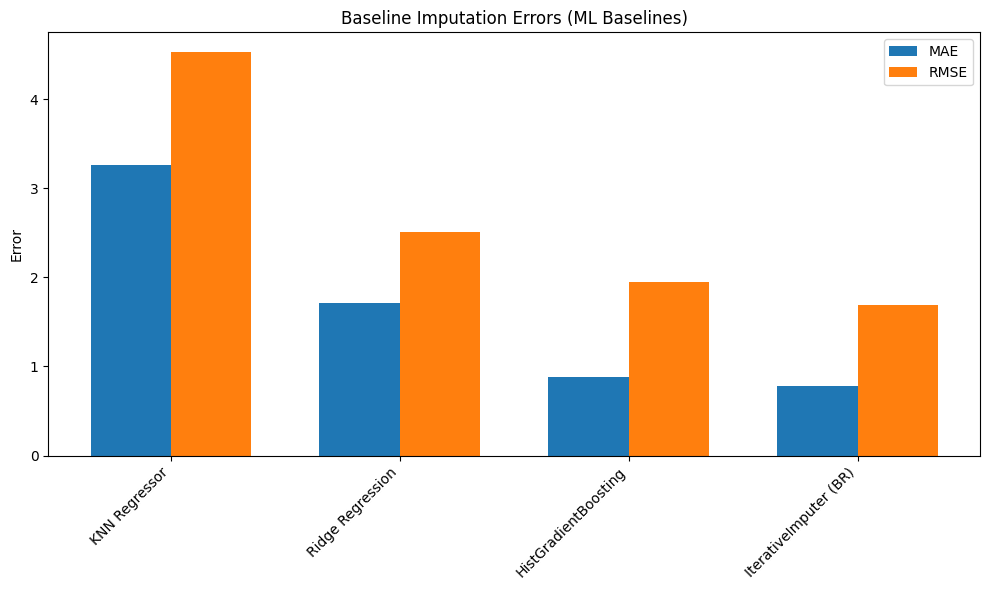

In [10]:
# === Section: Plotting I ===
# Plot the MAE and RMSE for each baseline in a bar chart
import matplotlib.pyplot as plt
baselines = ["KNN Regressor", "Ridge Regression", "HistGradientBoosting", "IterativeImputer (BR)"]
mae_values = [float(np.mean(np.abs(imputed_knn[~mask] - data[~mask]))),
              float(np.mean(np.abs(imputed_ridge[~mask] - data[~mask]))),
              float(np.mean(np.abs(imputed_hgb[~mask] - data[~mask]))),
              float(np.mean(np.abs(imputed_mice[~mask] - data[~mask])))]
rmse_values = [float(np.sqrt(np.mean((imputed_knn[~mask] - data[~mask]) ** 2))),
               float(np.sqrt(np.mean((imputed_ridge[~mask] - data[~mask]) ** 2))),
               float(np.sqrt(np.mean((imputed_hgb[~mask] - data[~mask]) ** 2))),
               float(np.sqrt(np.mean((imputed_mice[~mask] - data[~mask]) ** 2)))]
x = np.arange(len(baselines))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, mae_values, width, label='MAE')
rects2 = ax.bar(x + width/2, rmse_values, width, label='RMSE')
ax.set_ylabel('Error')
ax.set_title('Baseline Imputation Errors (ML Baselines)')
ax.set_xticks(x)
ax.set_xticklabels(baselines, rotation=45, ha='right')
ax.legend()
fig.tight_layout()
plt.show()

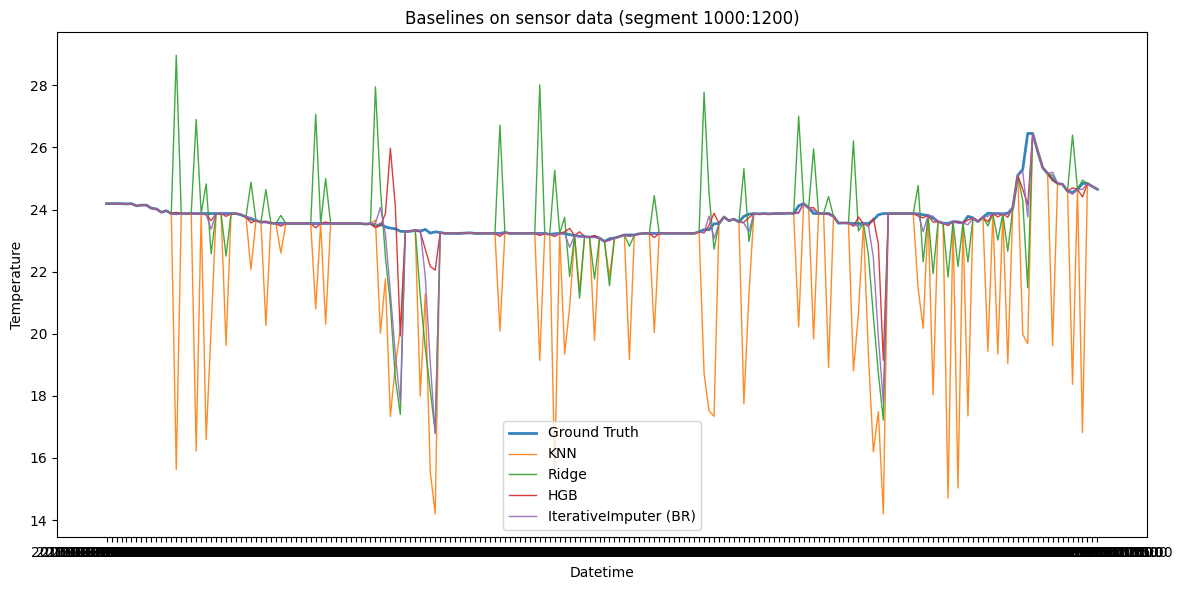

In [ ]:
# === Section: Plotting II ===
import matplotlib.pyplot as plt
segment_start, segment_end = 1000, 1200
plt.figure(figsize=(12, 6))
plt.plot(df.index[segment_start:segment_end], data[segment_start:segment_end], label='Ground Truth', linewidth=2, alpha=0.9)
plt.plot(df.index[segment_start:segment_end], imputed_knn[segment_start:segment_end], label='KNN', linewidth=1, alpha=0.9)
plt.plot(df.index[segment_start:segment_end], imputed_ridge[segment_start:segment_end], label='Ridge', linewidth=1, alpha=0.9)
plt.plot(df.index[segment_start:segment_end], imputed_hgb[segment_start:segment_end], label='HGB', linewidth=1, alpha=0.9)
plt.plot(df.index[segment_start:segment_end], imputed_mice[segment_start:segment_end], label='IterativeImputer (BR)', linewidth=1, alpha=0.9)
plt.title(f'Baselines on sensor data (segment {segment_start}:{segment_end})')
plt.xlabel('Datetime')
plt.ylabel('Temperature')
plt.legend()
plt.tight_layout()
plt.show()
